In [1]:
pip install scikeras

In [2]:
pip install --force-reinstall -v scikit-learn==1.4.2

Using pip 24.1.2 from /usr/local/lib/python3.12/dist-packages/pip (python 3.12)
  Obtaining dependency information for scikit-learn==1.4.2 from https://files.pythonhosted.org/packages/bc/f6/761881cb1cec60874be76831571c76d596bcf3d13959390e73f4c745086f/scikit_learn-1.4.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata
  Link requires a different Python (3.12.13 not in: '>=3.7,<3.11'): https://files.pythonhosted.org/packages/3a/be/650f9c091ef71cb01d735775d554e068752d3ff63d7943b26316dc401749/numpy-1.21.2.zip (from https://pypi.org/simple/numpy/) (requires-python:>=3.7,<3.11)
  Link requires a different Python (3.12.13 not in: '>=3.7,<3.11'): https://files.pythonhosted.org/packages/5f/d6/ad58ded26556eaeaa8c971e08b6466f17c4ac4d786cd3d800e26ce59cc01/numpy-1.21.3.zip (from https://pypi.org/simple/numpy/) (requires-python:>=3.7,<3.11)
  Link requires a different Python (3.12.13 not in: '>=3.7,<3.11'): https://files.pythonhosted.org/packages/fb/48/b0708ebd7718a8933f0d3937513e

### Seeds para reprodutibilidade

In [1]:
# Reprodutibilidade
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = '0'
import random
random.seed(1)
import numpy as np
np.random.seed(1)
import tensorflow as tf
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)
tf.config.experimental.enable_op_determinism()
tf.random.set_seed(1)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Geração de dados

In [3]:
np.random.seed(204258)

def sim_client(alfa, beta1, beta2, mu_erro, sigma_erro, n, cliente, a1, b1, a2, b2):
    np.random.seed(204258)
    X = []
    for i in range(n):
        X.append((np.random.uniform(a1, b1), np.random.uniform(a2, b2)))
    X = pd.DataFrame(X, columns=['x1','x2'])
    alfa = np.array([alfa] * n)
    beta1 = np.array([beta1] * n)
    beta2 = np.array([beta2] * n)
    erro = []
    for i in range(n):
        erro.append(np.random.normal(mu_erro, sigma_erro))
    erro = np.array(erro)
    pred_linear = alfa + beta1*X.iloc[:,0] + beta2*X.iloc[:,1] + erro
    p = 1/(1+np.exp(-pred_linear))
    y = np.random.binomial(1, p)
    dados_sim_client = X
    dados_sim_client['Resposta'] = y
    dados_sim_client['Cliente'] = np.array([cliente] * n)
    return(dados_sim_client)

dados_sim_c1 = sim_client(alfa = 1.5, beta1 = 2.5, beta2 = -2, mu_erro = 0, sigma_erro = 4, n = 30, cliente = '1', a1 = -10, b1 = 10, a2 = 0, b2 = 20)
dados_sim_c2 = sim_client(alfa = 1.5, beta1 = 2.6, beta2 = -1.9, mu_erro = 0, sigma_erro = 4, n = 40, cliente = '2', a1 = 0, b1 = 10, a2 = 0, b2 = 10)
dados_sim_c3 = sim_client(alfa = 1.3, beta1 = 2.5, beta2 = -2.1, mu_erro = 0, sigma_erro = 4, n = 50, cliente = '3', a1 = -10, b1 = 10, a2 = -5, b2 = 15)
dados_sim_total = pd.concat([dados_sim_c1, dados_sim_c2, dados_sim_c3], axis = 0)
# dados_sim_total.to_csv('Dados_Simulados_IC.csv', index = False)

Visualização dos dados

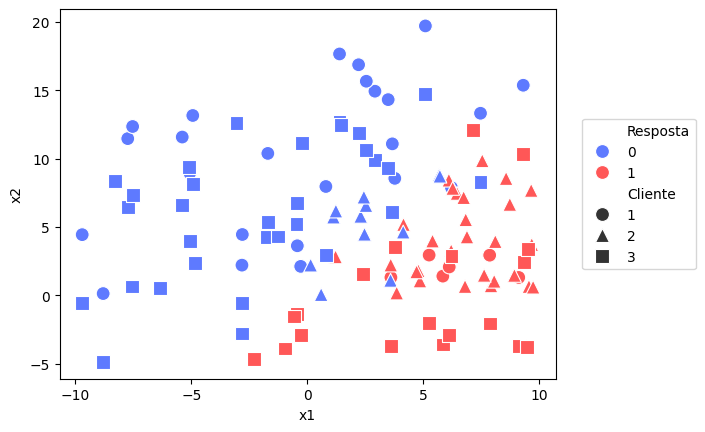

In [4]:
dispersao = sns.scatterplot(data = dados_sim_total, x = 'x1', y = 'x2', hue = 'Resposta', style = 'Cliente', markers = ['o','^','s'], palette=['#5E7AFF', '#FF5757'], s = 100)
sns.move_legend(obj = dispersao, loc = 'center left', bbox_to_anchor = (1.04,0.5), ncol = 1)
sns.set_theme(font_scale=1.75, style='white')
plt.savefig('dados_simulacao_ic.png', bbox_inches = 'tight')

### Separação em treino, validação e teste para cada cliente (Federado) e geral (Centralizado)

In [5]:
from sklearn.model_selection import train_test_split
np.random.seed(204258)
dados_sim_c1_treino, dados_sim_c1_teste = train_test_split(dados_sim_c1, test_size=0.3,random_state=204258)
dados_sim_c2_treino, dados_sim_c2_teste = train_test_split(dados_sim_c2, test_size=0.3,random_state=2)
dados_sim_c3_treino, dados_sim_c3_teste = train_test_split(dados_sim_c3, test_size=0.3,random_state=20)
conj_treino_total = pd.concat([dados_sim_c1_treino, dados_sim_c2_treino, dados_sim_c3_treino], axis = 0)
conj_teste_total = pd.concat([dados_sim_c1_teste, dados_sim_c2_teste, dados_sim_c3_teste], axis = 0)
fl_dados_sim_c1_treino, fl_dados_sim_c1_valid = train_test_split(dados_sim_c1_treino, test_size=0.3,random_state=204258)
fl_dados_sim_c2_treino, fl_dados_sim_c2_valid = train_test_split(dados_sim_c2_treino, test_size=0.3,random_state=2)
fl_dados_sim_c3_treino, fl_dados_sim_c3_valid = train_test_split(dados_sim_c3_treino, test_size=0.3,random_state=20)
fl_conj_treino_total = pd.concat([fl_dados_sim_c1_treino, fl_dados_sim_c2_treino, fl_dados_sim_c3_treino], axis = 0)
fl_conj_valid_total = pd.concat([fl_dados_sim_c1_valid, fl_dados_sim_c2_valid, fl_dados_sim_c3_valid], axis = 0)
fl_conj_teste_total = conj_teste_total.copy()

In [6]:
conj_treino_total = fl_conj_treino_total.copy()
conj_valid_total = fl_conj_valid_total.copy()

### Padronização dos dados do AF

In [7]:
soma_x = fl_conj_treino_total.groupby(by='Cliente').sum()
n_clientes = fl_conj_treino_total['Cliente'].value_counts()
soma_x2 = fl_conj_treino_total.copy()
soma_x2[['x1', 'x2']] = fl_conj_treino_total[['x1', 'x2']].pow(2)
soma_x2 = soma_x2.groupby(by='Cliente').sum()[['x1', 'x2']]
mean_fed = soma_x[['x1', 'x2']].sum() / sum(n_clientes)
std_fed = ((soma_x2[['x1', 'x2']].sum() - (soma_x[['x1', 'x2']].sum().pow(2) / sum(n_clientes))) / (sum(n_clientes) - 1)).pow(0.5)
fl_conj_treino_total['x1'] = (fl_conj_treino_total['x1'] - mean_fed.iloc[0])/std_fed.iloc[0]
fl_conj_treino_total['x2'] = (fl_conj_treino_total['x2'] - mean_fed.iloc[1])/std_fed.iloc[1]
fl_conj_valid_total['x1'] = (fl_conj_valid_total['x1'] - mean_fed.iloc[0])/std_fed.iloc[0]
fl_conj_valid_total['x2'] = (fl_conj_valid_total['x2'] - mean_fed.iloc[1])/std_fed.iloc[1]
#fl_conj_teste_total['x1'] = (fl_conj_teste_total['x1'] - mean_fed.iloc[0])/std_fed.iloc[0]
#fl_conj_teste_total['x2'] = (fl_conj_teste_total['x2'] - mean_fed.iloc[1])/std_fed.iloc[1]

In [8]:
fl_conj_treino_total.to_csv('IC_S_fl_conj_treino_total.csv', index = False)
fl_conj_valid_total.to_csv('IC_S_fl_conj_valid_total.csv', index = False)

In [9]:
fl_conj_treino_final = pd.concat([fl_conj_treino_total, fl_conj_valid_total])
soma_x = fl_conj_treino_final.groupby(by='Cliente').sum()
n_clientes = fl_conj_treino_final['Cliente'].value_counts()
soma_x2 = fl_conj_treino_final.copy()
soma_x2[['x1', 'x2']] = fl_conj_treino_final[['x1', 'x2']].pow(2)
soma_x2 = soma_x2.groupby(by='Cliente').sum()[['x1', 'x2']]
mean_fed = soma_x[['x1', 'x2']].sum() / sum(n_clientes)
std_fed = ((soma_x2[['x1', 'x2']].sum() - (soma_x[['x1', 'x2']].sum().pow(2) / sum(n_clientes))) / (sum(n_clientes) - 1)).pow(0.5)
fl_conj_treino_final['x1'] = (fl_conj_treino_final['x1'] - mean_fed.iloc[0])/std_fed.iloc[0]
fl_conj_treino_final['x2'] = (fl_conj_treino_final['x2'] - mean_fed.iloc[1])/std_fed.iloc[1]
fl_conj_teste_total['x1'] = (fl_conj_teste_total['x1'] - mean_fed.iloc[0])/std_fed.iloc[0]
fl_conj_teste_total['x2'] = (fl_conj_teste_total['x2'] - mean_fed.iloc[1])/std_fed.iloc[1]

In [10]:
fl_conj_treino_final.to_csv('IC_S_fl_conj_treino_final.csv', index = False)

In [11]:
# random.seed(1)
# np.random.seed(1)
# tf.config.threading.set_intra_op_parallelism_threads(1)
# tf.config.threading.set_inter_op_parallelism_threads(1)
# tf.config.experimental.enable_op_determinism()
# tf.random.set_seed(1)

### Grid Search do AM Centralizado (Padronização está no Pipeline)

In [12]:
# sklearn versão 1.6.1 dá erro, usei 1.4.2
import sklearn
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from scikeras.wrappers import KerasClassifier
from tensorflow import keras
from tensorflow.keras import layers, initializers
from tensorflow.keras.callbacks import EarlyStopping

In [13]:
ps = PredefinedSplit(np.hstack((np.ones(len(fl_conj_treino_total))*(-1),np.ones(len(fl_conj_valid_total))*0)))
#scaler_cen = StandardScaler()
#scaled_conj_treino_total = conj_treino_total.copy()
#scaled_conj_valid_total = conj_valid_total.copy()
#scaled_conj_teste_total = conj_teste_total.copy()
#scaled_conj_treino_total[['x1', 'x2']] = scaler_cen.fit_transform(conj_treino_total[['x1', 'x2']])
#scaled_conj_valid_total[['x1', 'x2']] = scaler_cen.transform(conj_valid_total[['x1', 'x2']])
#scaled_conj_teste_total[['x1', 'x2']] = scaler_cen.transform(conj_teste_total[['x1', 'x2']])

In [14]:
# Funcao para gerar redes neurais para selecao de hiperparametros
def get_clf(hidden_layer_sizes, hidden_layer_num):
    model = tf.keras.Sequential()
    model.add(tf.keras.Input(shape=(2,)))
    for i in range(hidden_layer_num):
        model.add(
            layers.Dense(
                units=hidden_layer_sizes,
                activation='relu',
                kernel_initializer = initializers.GlorotUniform(seed=1),
                bias_initializer = 'zeros'
        )
    )
    model.add(layers.Dense(1, activation='sigmoid', kernel_initializer = initializers.GlorotUniform(seed=1), bias_initializer = 'zeros'))
    # model.compile(
    #     optimizer = keras.optimizers.SGD(learning_rate=learning_rate),
    #     loss='binary_crossentropy',
    #     metrics=['accuracy']
    return model

In [15]:
model_params = {
    'log_reg': {
        'model': Pipeline([('scaler', StandardScaler()),
                           ('log_reg', LogisticRegression())]),
        'params': {
            'log_reg__random_state': [1]
        }
    },
    'svm': {
        'model': Pipeline([('scaler', StandardScaler()),
                           ('SVC', SVC())]),
        'params': {
            'SVC__C': [0.1, 1, 10, 100],
            'SVC__kernel': ['linear', 'poly', 'rbf'],
            'SVC__random_state': [1]
        }
    },
    'knn': {
        'model': Pipeline([('scaler', StandardScaler()),
                           ('KNN', KNeighborsClassifier())]),
        'params': {
            'KNN__n_neighbors': [3, 5, 7]
        }
    },
    'naive_bayes': {
        'model': Pipeline([('scaler', StandardScaler()),
                           ('nb', GaussianNB())]),
        'params': {}
    },
    'tree': {
        'model': Pipeline([('scaler', StandardScaler()),
                           ('dt', DecisionTreeClassifier())]),
        'params': {
            'dt__max_depth': [1, 2, 3, None],
            'dt__min_samples_split': [2, 3, 5],
            'dt__random_state': [1]
        }
    },
    'random_forest': {
        'model': Pipeline([('scaler', StandardScaler()),
                           ('rf', RandomForestClassifier())]),
        'params': {
            'rf__max_depth': [1, 2, 3, None],
            'rf__min_samples_split': [2, 3, 5],
            'rf__random_state': [1]
        }
    },
    'nn': {
        'model': Pipeline([('scaler', StandardScaler()),
                           ('keras', KerasClassifier(model=get_clf, random_state = 1, loss='binary_crossentropy', optimizer='sgd', verbose=False, epochs = 10,
                                           callbacks=[EarlyStopping(patience=10, restore_best_weights=True,monitor='loss')]))]),
        'params':{
            'keras__model__hidden_layer_sizes': [100, 200, 300, 400],
            'keras__model__hidden_layer_num': [1, 2, 3]
        }
    }
}
scores = []
for model_name, mp in model_params.items():
    clf = GridSearchCV(mp['model'], mp['params'], cv = ps, return_train_score=False, scoring = 'accuracy')
    clf.fit(pd.concat([conj_treino_total[['x1', 'x2']], conj_valid_total[['x1', 'x2']]]), pd.concat([conj_treino_total['Resposta'], conj_valid_total['Resposta']]))
    scores.append({
    'model': model_name,
    'best_score': clf.best_score_,
    'best_params': clf.best_params_
    })
validacao = pd.DataFrame(scores, columns=['model', 'best_score', 'best_params'])
validacao
validacao.iloc[6,2]

{'keras__model__hidden_layer_num': 1, 'keras__model__hidden_layer_sizes': 400}

In [16]:
validacao

,model,best_score,best_params
0,log_reg,0.925926,{'log_reg__random_state': 1}
1,svm,1.000000,"{'SVC__C': 0.1, 'SVC__kernel': 'rbf', 'SVC__ra..."
2,knn,0.925926,{'KNN__n_neighbors': 3}
3,naive_bayes,0.962963,{}
4,tree,0.925926,"{'dt__max_depth': 1, 'dt__min_samples_split': ..."
5,random_forest,0.962963,"{'rf__max_depth': 3, 'rf__min_samples_split': ..."
6,nn,0.962963,"{'keras__model__hidden_layer_num': 1, 'keras__..."


In [17]:
nn = tf.keras.Sequential()
nn.add(tf.keras.Input(shape=(2,)))
nn.add(layers.Dense(400, activation='relu', kernel_initializer = initializers.GlorotUniform(seed=1), bias_initializer = 'zeros'))
nn.add(layers.Dense(1, activation='sigmoid', kernel_initializer = initializers.GlorotUniform(seed=1), bias_initializer = 'zeros'))
nn.compile(loss='binary_crossentropy',
              optimizer = 'sgd',
              metrics = ['accuracy'])
#scaled_nn.fit(scaled_conj_treino_total[['x1', 'x2']], conj_treino_total['Resposta'], epochs = 10, verbose = False, callbacks=[EarlyStopping(patience=10, restore_best_weights=True,monitor='loss')])
nn.save(filepath='nn_neural_sim_ic.keras')

### Repadronização após grid search (ajuste em treino e validação e aplicação no teste)

In [18]:
sc_final = StandardScaler()
conj_treino_final = pd.concat([conj_treino_total, conj_valid_total])
conj_treino_final[['x1', 'x2']] = sc_final.fit_transform(conj_treino_final[['x1', 'x2']])
conj_teste_total[['x1', 'x2']] = sc_final.transform(conj_teste_total[['x1', 'x2']])

### Ajuste final dos modelos

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, b

37813/37813 ━━━━━━━━━━━━━━━━━━━━ 49s 1ms/step
37813/37813 ━━━━━━━━━━━━━━━━━━━━ 46s 1ms/step


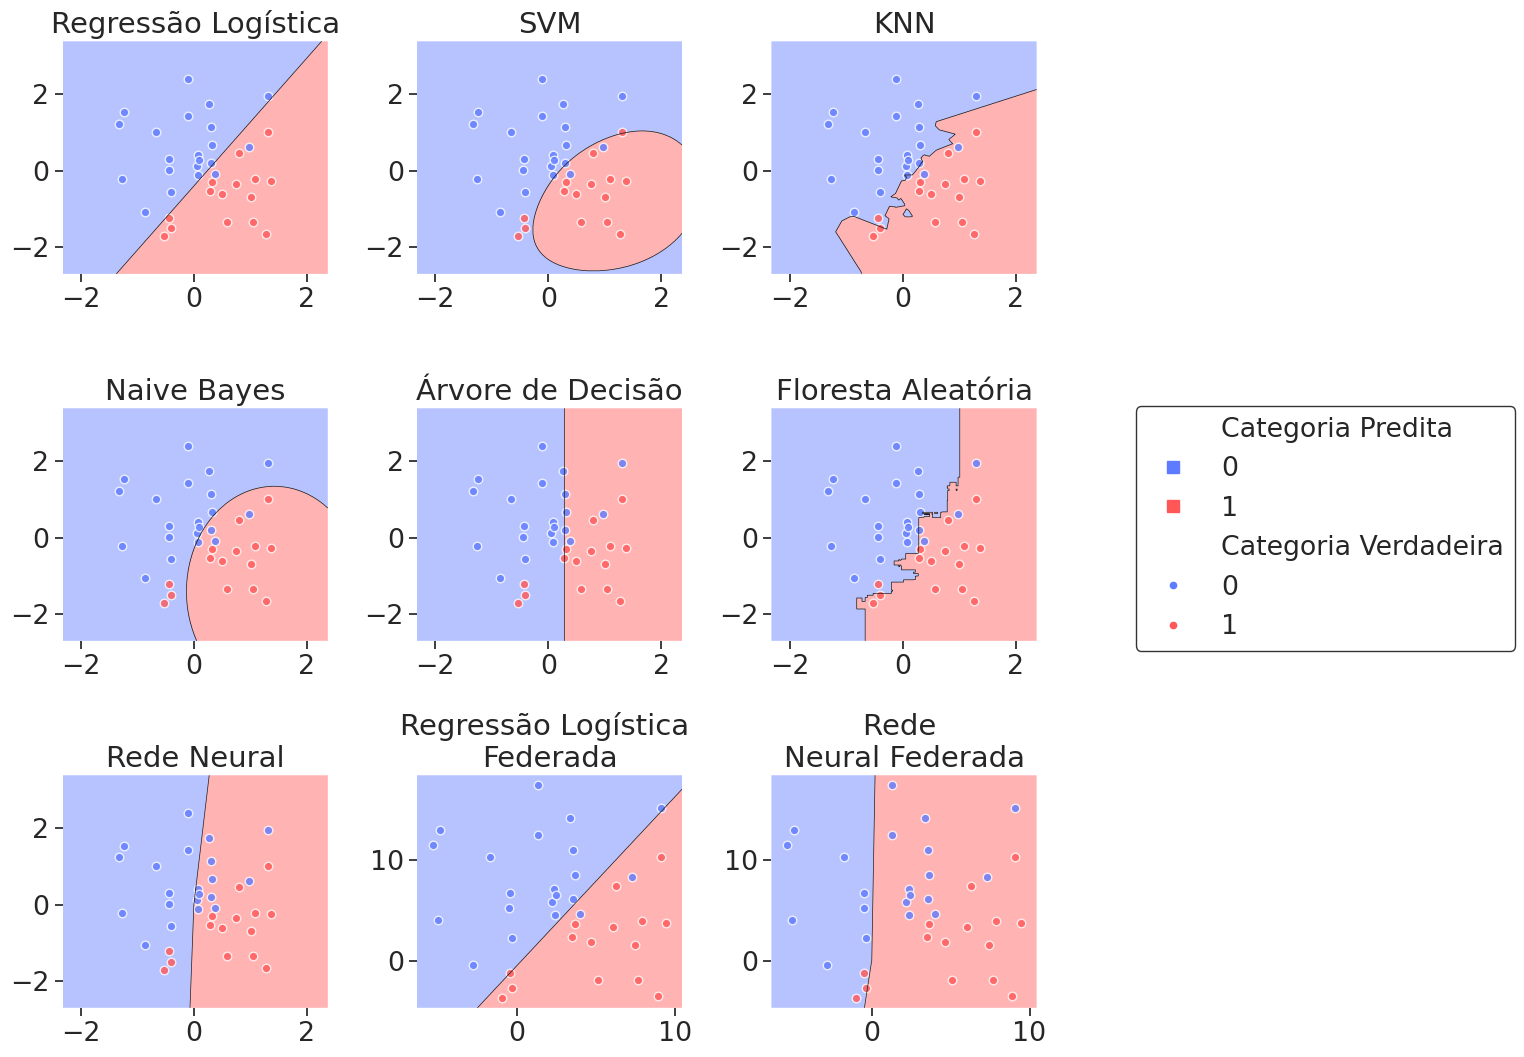

In [20]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
import matplotlib.gridspec as gridspec
import itertools
import joblib
from matplotlib.lines import Line2D

log_reg = LogisticRegression(random_state = 1)
svm = SVC(C =0.1, kernel='rbf', random_state = 1, probability=True)
knn = KNeighborsClassifier(n_neighbors=3)
naive_bayes = GaussianNB()
tree = DecisionTreeClassifier(max_depth= 1, min_samples_split=2, random_state = 1)
rf = RandomForestClassifier(max_depth = 3, min_samples_split = 2, random_state = 1)
nn = tf.keras.models.load_model("/content/nn_neural_sim_ic.keras")
fl_log_reg = joblib.load("/content/modelo_final_logreg_sim_ic")
fl_nn = tf.keras.models.load_model("/content/modelo_neural_sim_ic_final.keras")
classif_cen = [log_reg, svm, knn, naive_bayes, tree, rf]
nomes = ['Regressão Logística','SVM','KNN','Naive Bayes','Árvore de Decisão','Floresta Aleatória','Rede Neural']
for clf in classif_cen:
    clf.fit(conj_treino_final[['x1', 'x2']], conj_treino_final['Resposta'])

gs = gridspec.GridSpec(3,3)
fig = plt.figure(figsize=(11,11))
sns.set_theme(font_scale=1.75, style='white')

classificadores = [log_reg, svm, knn, naive_bayes, tree, rf, nn]
for clf, lab, grd in zip(classificadores, nomes, list(itertools.product([0,1,2], repeat=2))[0:7]):
    ax = plt.subplot(gs[grd[0], grd[1]])
    fig = plot_decision_regions(X=conj_teste_total[['x1', 'x2']].to_numpy(), y=conj_teste_total['Resposta'].to_numpy(), clf=clf,
                                legend = None, markers = ['.','.'], scatter_kwargs = {'s': 150, 'edgecolor': 'white'},
                                colors = '#5E7AFF,#FF5757')
    plt.title(lab)
for clf, lab, grd in zip([fl_log_reg, fl_nn], ['Regressão Logística \nFederada', 'Rede \nNeural Federada'], list(itertools.product([0,1,2], repeat=2))[7:9]):
    ax = plt.subplot(gs[grd[0], grd[1]])
    fig = plot_decision_regions(X=fl_conj_teste_total[['x1', 'x2']].to_numpy(), y=fl_conj_teste_total['Resposta'].to_numpy(), clf=clf,
                                legend = None, markers = ['.','.'], scatter_kwargs = {'s': 150, 'edgecolor': 'white'},
                                colors = '#5E7AFF,#FF5757')
    plt.title(lab)
custom = [
        (Line2D([], [], linestyle = 'None', marker = '')),
        (Line2D([], [], color = '#5E7AFF', linestyle = 'None', marker = 's')),
        (Line2D([], [], color = '#FF5757', linestyle = 'None', marker = 's')),
        (Line2D([], [], linestyle = 'None')),
        (Line2D([], [], color = '#5E7AFF', linestyle = 'None', marker = '.')),
        (Line2D([], [], color = '#FF5757', linestyle = 'None', marker = '.'))]
plt.tight_layout()
plt.figlegend(handles = custom, labels = ['Categoria Predita', '0', '1', 'Categoria Verdadeira', '0', '1'], loc = 'center left', bbox_to_anchor = (1.04, 0.5), markerscale = 1.5, edgecolor = 'black')
plt.savefig('scaled_fronteiras_decisao__.png', bbox_inches = 'tight')
plt.show()

In [21]:
from sklearn.metrics import accuracy_score

In [22]:
for i in [log_reg, svm, knn, naive_bayes, tree, rf]:
    print(round(accuracy_score(y_true = conj_teste_total['Resposta'], y_pred = i.predict(conj_teste_total[['x1', 'x2']])), ndigits=3))


0.944
0.833
0.889
0.806
0.75
0.861


In [23]:
print(round(accuracy_score(y_true = fl_conj_teste_total['Resposta'], y_pred = fl_log_reg.predict(fl_conj_teste_total[['x1', 'x2']])), ndigits=3))
nn_predict = (nn.predict(conj_teste_total[['x1', 'x2']]) > 0.5).astype('int32')
fl_nn_predict = (fl_nn.predict(fl_conj_teste_total[['x1', 'x2']]) > 0.5).astype('int32')
print(round(accuracy_score(y_true = conj_teste_total['Resposta'], y_pred = nn_predict), ndigits=3))
print(round(accuracy_score(y_true = fl_conj_teste_total['Resposta'], y_pred = fl_nn_predict), ndigits=3))

0.917
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
0.611
0.556


In [24]:
nomes = ["Regressão Logística", "SVM", "KNN", "Naive Bayes", "Árvore de Decisão", "Floresta Aleatória", "Regressão Logística", "Rede Neural", "Rede Neural"]
tipo = ["Centralizado",  "Centralizado", "Centralizado", "Centralizado", "Centralizado", "Centralizado", "Federado", "Centralizado", "Federado"]
acuracia = [round(accuracy_score(y_true = conj_teste_total['Resposta'], y_pred = log_reg.predict(conj_teste_total[['x1', 'x2']])), ndigits=3),
            round(accuracy_score(y_true = conj_teste_total['Resposta'], y_pred = svm.predict(conj_teste_total[['x1', 'x2']])), ndigits=3),
            round(accuracy_score(y_true = conj_teste_total['Resposta'], y_pred = knn.predict(conj_teste_total[['x1', 'x2']])), ndigits=3),
            round(accuracy_score(y_true = conj_teste_total['Resposta'], y_pred = naive_bayes.predict(conj_teste_total[['x1', 'x2']])), ndigits=3),
            round(accuracy_score(y_true = conj_teste_total['Resposta'], y_pred = tree.predict(conj_teste_total[['x1', 'x2']])), ndigits=3),
            round(accuracy_score(y_true = conj_teste_total['Resposta'], y_pred = rf.predict(conj_teste_total[['x1', 'x2']])), ndigits=3),
            round(accuracy_score(y_true = fl_conj_teste_total['Resposta'], y_pred = fl_log_reg.predict(fl_conj_teste_total[['x1', 'x2']])), ndigits=3),
            round(accuracy_score(y_true = conj_teste_total['Resposta'], y_pred = nn_predict), ndigits=3),
            round(accuracy_score(y_true = fl_conj_teste_total['Resposta'], y_pred = fl_nn_predict), ndigits=3)]
dados_acuracia = {
    "Nome": nomes,
    "Tipo": tipo,
    "Acurácia": acuracia
}
df_acuracia = pd.DataFrame(dados_acuracia)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


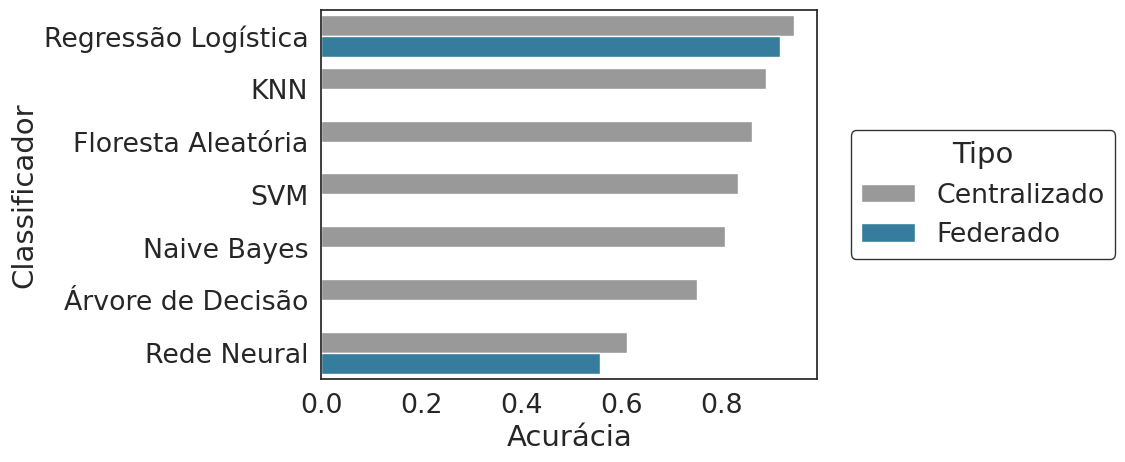

In [25]:
ac_barras = sns.barplot(data = df_acuracia.sort_values('Acurácia', ascending=False), x = 'Acurácia', y = 'Nome', hue = 'Tipo', palette=['#999999', '#2582AD'])
sns.move_legend(obj = ac_barras, loc = 'center left', bbox_to_anchor = (1.04,0.5), ncol = 1, edgecolor = 'black')
sns.set_theme(font_scale=1.75, style='white')
plt.ylabel("Classificador")
plt.savefig('acuracia_simulacao_ic.png', bbox_inches = 'tight')



In [26]:
from sklearn.metrics import roc_curve, roc_auc_score

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Text(0, 0.5, 'TPR')

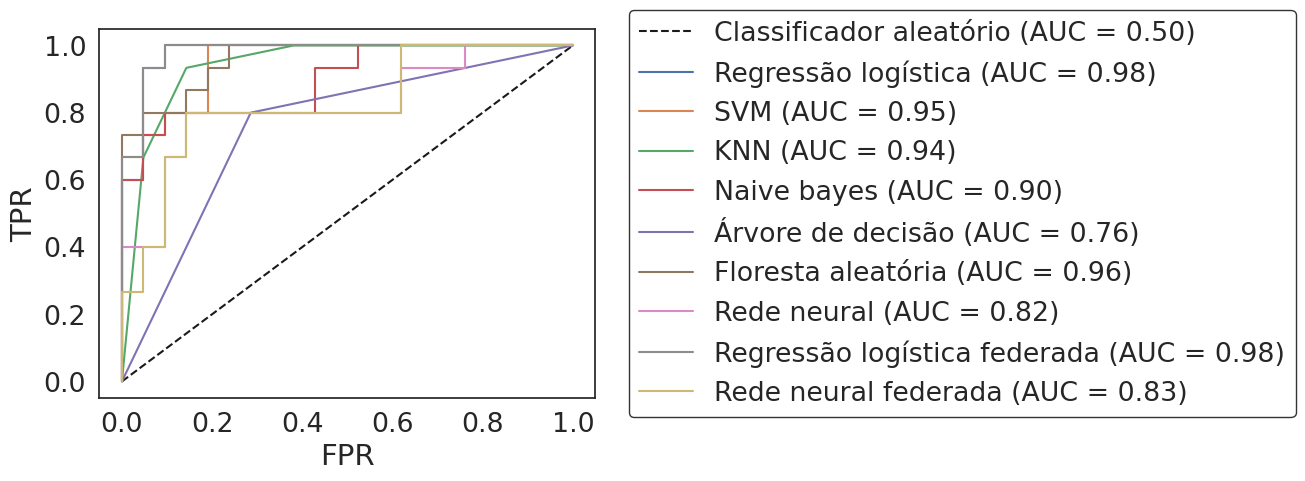

In [27]:
fpr_log_reg, tpr_log_reg, thresholds_log_reg = roc_curve(conj_teste_total['Resposta'], log_reg.predict_proba(conj_teste_total[['x1', 'x2']])[:,1])
auc_log_reg = roc_auc_score(conj_teste_total['Resposta'], log_reg.predict_proba(conj_teste_total[['x1', 'x2']])[:,1])

fpr_svm, tpr_svm, thresholds_svm = roc_curve(conj_teste_total['Resposta'], svm.predict_proba(conj_teste_total[['x1', 'x2']])[:,1])
auc_svm = roc_auc_score(conj_teste_total['Resposta'], svm.predict_proba(conj_teste_total[['x1', 'x2']])[:,1])

fpr_knn, tpr_knn, thresholds_knn = roc_curve(conj_teste_total['Resposta'], knn.predict_proba(conj_teste_total[['x1', 'x2']])[:,1])
auc_knn = roc_auc_score(conj_teste_total['Resposta'], knn.predict_proba(conj_teste_total[['x1', 'x2']])[:,1])

fpr_naive_bayes, tpr_naive_bayes, thresholds_naive_bayes = roc_curve(conj_teste_total['Resposta'], naive_bayes.predict_proba(conj_teste_total[['x1', 'x2']])[:,1])
auc_naive_bayes = roc_auc_score(conj_teste_total['Resposta'], naive_bayes.predict_proba(conj_teste_total[['x1', 'x2']])[:,1])

fpr_tree, tpr_tree, thresholds_tree = roc_curve(conj_teste_total['Resposta'], tree.predict_proba(conj_teste_total[['x1', 'x2']])[:,1])
auc_tree = roc_auc_score(conj_teste_total['Resposta'], tree.predict_proba(conj_teste_total[['x1', 'x2']])[:,1])

fpr_rf, tpr_rf, thresholds_rf = roc_curve(conj_teste_total['Resposta'], rf.predict_proba(conj_teste_total[['x1', 'x2']])[:,1])
auc_rf = roc_auc_score(conj_teste_total['Resposta'], rf.predict_proba(conj_teste_total[['x1', 'x2']])[:,1])

fpr_fl_log_reg, tpr_fl_log_reg, thresholds_fl_log_reg = roc_curve(conj_teste_total['Resposta'], fl_log_reg.predict_proba(conj_teste_total[['x1', 'x2']])[:,1])
auc_fl_log_reg = roc_auc_score(conj_teste_total['Resposta'], fl_log_reg.predict_proba(conj_teste_total[['x1', 'x2']])[:,1])

fpr_nn, tpr_nn, thresholds_nn = roc_curve(conj_teste_total['Resposta'], nn.predict(conj_teste_total[['x1', 'x2']], verbose = 0))
auc_nn = roc_auc_score(conj_teste_total['Resposta'], nn.predict(conj_teste_total[['x1', 'x2']], verbose = 0))

fpr_fl_nn, tpr_fl_nn, thresholds_fl_nn = roc_curve(conj_teste_total['Resposta'], fl_nn.predict(conj_teste_total[['x1', 'x2']], verbose = 0))
auc_fl_nn = roc_auc_score(conj_teste_total['Resposta'], fl_nn.predict(conj_teste_total[['x1', 'x2']], verbose = 0))

plt.plot([0,1], [0, 1], 'k--', label = 'Classificador aleatório (AUC = 0.50)')
plt.plot(fpr_log_reg, tpr_log_reg, label = f"Regressão logística (AUC = {auc_log_reg:.2f})")
plt.plot(fpr_svm, tpr_svm, label = f'SVM (AUC = {auc_svm:.2f})')
plt.plot(fpr_knn, tpr_knn, label = f'KNN (AUC = {auc_knn:.2f})')
plt.plot(fpr_naive_bayes, tpr_naive_bayes, label = f'Naive bayes (AUC = {auc_naive_bayes:.2f})')
plt.plot(fpr_tree, tpr_tree, label = f'Árvore de decisão (AUC = {auc_tree:.2f})')
plt.plot(fpr_rf, tpr_rf, label = f'Floresta aleatória (AUC = {auc_rf:.2f})')
plt.plot(fpr_nn, tpr_nn, label = f'Rede neural (AUC = {auc_nn:.2f})')
plt.plot(fpr_fl_log_reg, tpr_fl_log_reg, label = f'Regressão logística federada (AUC = {auc_fl_log_reg:.2f})')
plt.plot(fpr_fl_nn, tpr_fl_nn, label = f'Rede neural federada (AUC = {auc_fl_nn:.2f})')
plt.legend(bbox_to_anchor=(1.04, 0.5), loc = 'center left', edgecolor = 'black')
plt.xlabel('FPR')
plt.ylabel('TPR')

In [28]:
from sklearn.tree import export_graphviz

In [29]:
img_tree = export_graphviz(tree, feature_names=['x1', 'x2'], class_names=['0', '1'], rounded=True, filled = True)

In [30]:
img_tree = img_tree.replace('gini', 'Índice de Gini')
img_tree = img_tree.replace('samples', 'Amostras')
img_tree = img_tree.replace('value', 'Distribuição')
img_tree = img_tree.replace('class', 'Classe')
img_tree = img_tree.replace('True', 'Verdadeiro')
img_tree = img_tree.replace('False', 'Falso')

In [31]:
import graphviz

In [32]:
diag_tree = graphviz.Source(img_tree)
diag_tree.render('diag_tree', format = 'png', cleanup = False)

'diag_tree.png'